# TalentMatch AI

## Resume Dataset Exploration

### Objective
The objective of this notebook is to:

- Load the resume dataset
- Understand the dataset structure
- Explore resume categories
- Analyze the distribution of resumes
- Prepare the dataset for NLP preprocessing

This notebook represents the Exploratory Data Analysis (EDA) phase of the project.


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


# Load Resume Dataset

In [34]:
import pandas as pd

for enc in ["utf-8", "latin1", "cp1252"]:
    try:
        df = pd.read_csv(
            "../data/resumes/Resume/Resume.csv",
            encoding=enc
        )
        print(f"SUCCESS: {enc}")
        print(df.shape)
        break

    except Exception as e:
        print(f"FAILED: {enc}")
        print(e)

FAILED: utf-8
'utf-8' codec can't decode byte 0x96 in position 323: invalid start byte
SUCCESS: latin1
(3444, 169)


# Dataset Columns Exploration

In [35]:
print("Total Columns:", len(df.columns))
print(df.columns.tolist())

Total Columns: 169
['ID', 'Resume_str', 'Resume_html', 'Category', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unnamed: 60', 'Unnamed: 61', 'Unnamed: 62', 'Unnamed: 63', 'Unnamed: 64', 'Unnamed: 65', 'Unnamed:

In [36]:
df.head()


,ID,Resume_str,Resume_html,Category,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 159,Unnamed: 160,Unnamed: 161,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3444 entries, 0 to 3443
Columns: 169 entries, ID to Unnamed: 168
dtypes: str(169)
memory usage: 4.4 MB


# Data Cleaning

In [38]:
df = df[
    [
        "ID",
        "Resume_str",
        "Resume_html",
        "Category"
    ]
]

print(df.shape)

(3444, 4)


In [39]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')


In [40]:
df.isnull().sum()

ID             114
Resume_str     730
Resume_html    823
Category       908
dtype: int64

In [41]:
df.to_csv(
    "../data/processed/clean_resume_dataset.csv",
    index=False
)

In [42]:
df["Category"].value_counts()

Category
INFORMATION-TECHNOLOGY                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      119
BUSINESS-DEVELOPMENT                                                                                                                                                                                                                                                                                                                           

c:\Users\KIIT\OneDrive\Desktop\TalentMatch_AI\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


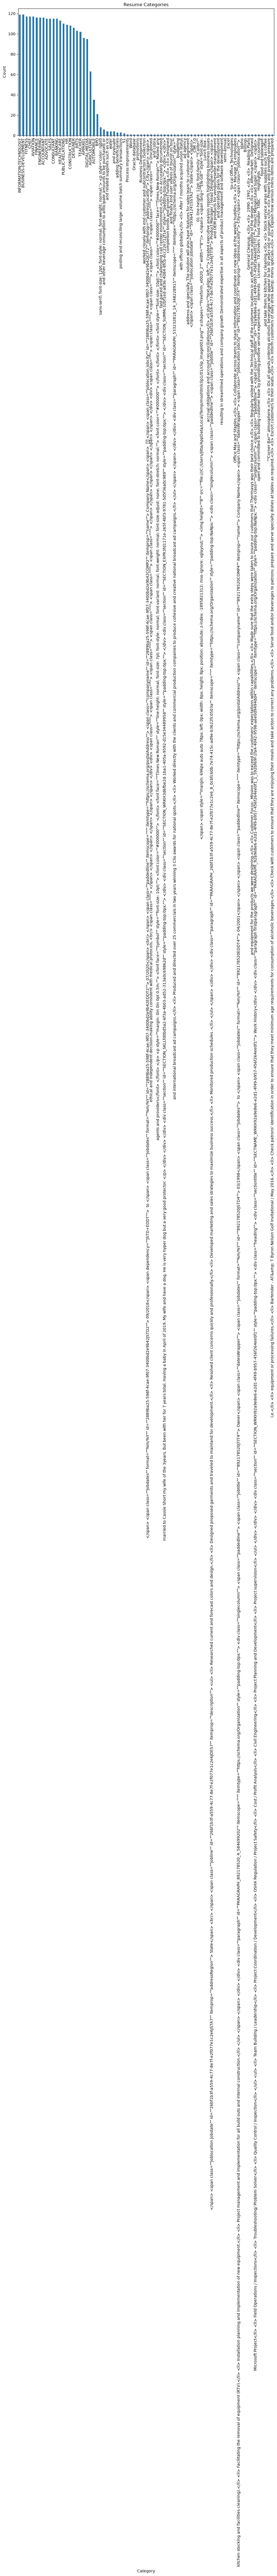

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [44]:
df["Category"].head(20)

0     HR
1     HR
2     HR
3     HR
4     HR
5     HR
6     HR
7     HR
8     HR
9     HR
10    HR
11    HR
12    HR
13    HR
14    HR
15    HR
16    HR
17    HR
18    HR
19    HR
Name: Category, dtype: str

In [45]:
df["Category"].sample(20)

2800                ACCOUNTANT
2714                       NaN
38                          HR
2030                       NaN
1460                       NaN
2093                       NaN
852                    FITNESS
2711               ENGINEERING
168                   DESIGNER
1045                     SALES
1159                CONSULTANT
3100          PUBLIC-RELATIONS
103                         HR
2480                   FINANCE
254     INFORMATION-TECHNOLOGY
2704               ENGINEERING
2676               ENGINEERING
3327                  AVIATION
3092          PUBLIC-RELATIONS
2389                       NaN
Name: Category, dtype: str

In [46]:
print(df.iloc[0])

ID                                                      16852973
Resume_str              HR ADMINISTRATOR/MARKETING ASSOCIATE\...
Resume_html    <div class="fontsize fontface vmargins hmargin...
Category                                                      HR
Name: 0, dtype: str


# Category Cleaning

In [47]:
print("Missing Categories:")
print(df["Category"].isnull().sum())

Missing Categories:
908


In [48]:
df = df.dropna(subset=["Category"])

In [49]:
print(df["Category"].isnull().sum())
print(df.shape)

0
(2536, 4)


In [50]:
sorted(df["Category"].unique())

[' ""Corner Bar"" atmosphere.</li> <li> IDs all guests ordering alcoholic beverages who appear to be 30 years old or younger.</li> <li> Properly and promptly prepare',
 ' 0); line-height: 12pt; font-family: ""Calibri""',
 ' </span> <span class=""jobdates"" format=""%m/%Y"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42JSTD2""> 09/2018</span> <span dependency=""JSTD+EDDT"">  to </span> <span class=""jobdates"" format=""%m/%Y"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42EDDT2""> 07/2020</span> <br/> </span> <span class=""paddedline"" itemscope="""" itemtype=""https://schema.org/postalAddress""> <span class=""companyname"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42COMP2"" itemprop=""name""> Company Name</span> <span>  \x96 </span> <span class=""joblocation jobcity"" id=""2889ba25-598f-4cae-9f07-3400bd2e9b42JCIT2"" itemprop=""addressLocality""> City</span> <span> ',
 ' </span> <span class=""joblocation jobstate"" id=""26bf1b3f-a559-4c77-8e7f-e2f077e1c2e6JSTA7"" itemprop=""addressRegion""> State</s

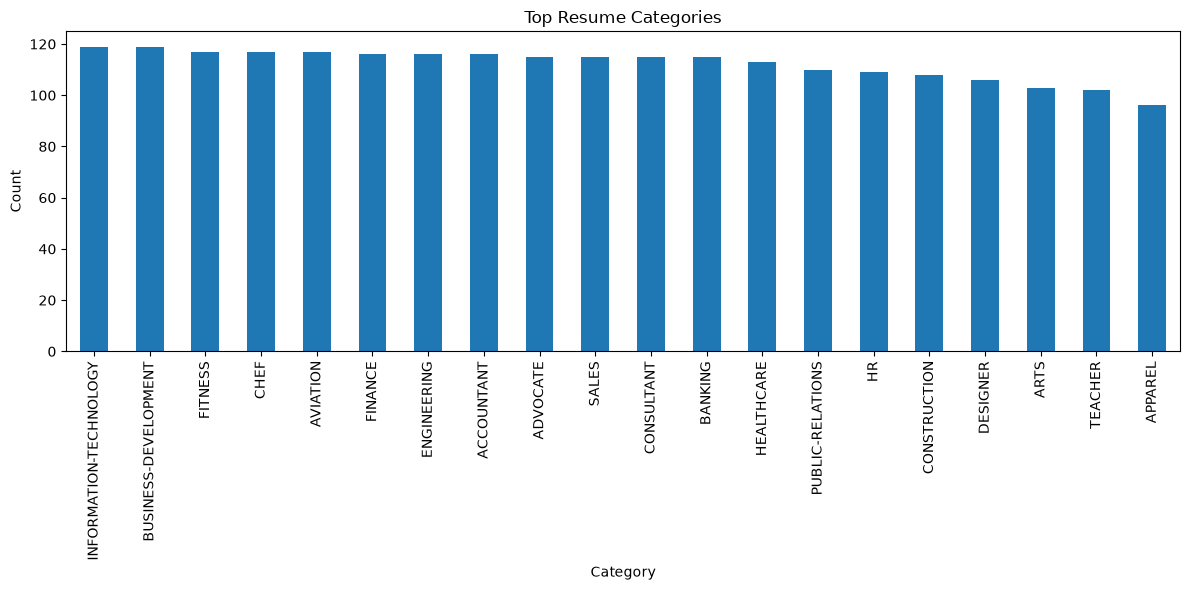

In [51]:
plt.figure(figsize=(12,6))

df["Category"].value_counts().head(20).plot(kind="bar")

plt.title("Top Resume Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [52]:
valid_categories = [
    "ACCOUNTANT",
    "ADVOCATE",
    "AGRICULTURE",
    "APPAREL",
    "ARTS",
    "AUTOMOBILE",
    "AVIATION",
    "BANKING",
    "BPO",
    "BUSINESS-DEVELOPMENT",
    "CHEF",
    "CONSTRUCTION",
    "CONSULTANT",
    "DESIGNER",
    "DIGITAL-MEDIA",
    "ENGINEERING",
    "FINANCE",
    "FITNESS",
    "HEALTHCARE",
    "HR",
    "INFORMATION-TECHNOLOGY",
    "PUBLIC-RELATIONS",
    "SALES",
    "TEACHER"
]

In [53]:
df = df[df["Category"].isin(valid_categories)]

In [54]:
print(df.shape)

(2458, 4)


In [55]:
sorted(df["Category"].unique())

['ACCOUNTANT',
 'ADVOCATE',
 'AGRICULTURE',
 'APPAREL',
 'ARTS',
 'AUTOMOBILE',
 'AVIATION',
 'BANKING',
 'BPO',
 'BUSINESS-DEVELOPMENT',
 'CHEF',
 'CONSTRUCTION',
 'CONSULTANT',
 'DESIGNER',
 'DIGITAL-MEDIA',
 'ENGINEERING',
 'FINANCE',
 'FITNESS',
 'HEALTHCARE',
 'HR',
 'INFORMATION-TECHNOLOGY',
 'PUBLIC-RELATIONS',
 'SALES',
 'TEACHER']

In [56]:
df.to_csv(
    "../data/processed/final_clean_resume_dataset.csv",
    index=False
)

## Final Summary

1. Removed 165 redundant columns.
2. Removed rows with missing categories.
3. Filtered corrupted category labels.
4. Retained 24 valid professional categories.
5. Generated a cleaned dataset for NLP processing.

In [57]:
df["Category"].value_counts().head(50)

Category
INFORMATION-TECHNOLOGY    119
BUSINESS-DEVELOPMENT      119
FITNESS                   117
CHEF                      117
AVIATION                  117
FINANCE                   116
ENGINEERING               116
ACCOUNTANT                116
ADVOCATE                  115
SALES                     115
CONSULTANT                115
BANKING                   115
HEALTHCARE                113
PUBLIC-RELATIONS          110
HR                        109
CONSTRUCTION              108
DESIGNER                  106
ARTS                      103
TEACHER                   102
APPAREL                    96
DIGITAL-MEDIA              95
AGRICULTURE                63
AUTOMOBILE                 35
BPO                        21
Name: count, dtype: int64